In [ ]:
# Mount Google Drive to access input/output data
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Install required libraries
# rioxarray        : raster I/O and CRS-aware clipping built on xarray + rasterio
# hvplot/holoviews : interactive plot rendering
# panel/bokeh      : interactive widget backend for Colab
# datashader       : rasterization of large arrays for fast rendering
# jupyter_bokeh    : Bokeh widget integration for Jupyter/Colab
!pip install rioxarray hvplot panel holoviews bokeh datashader jupyter_bokeh


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.5/175.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.6/148.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.5 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7

Loading LST data from: /content/drive/MyDrive/Coral PDRDF/ECOSTRESS Tifs/Geolocated LST/Merged Days/masked_output/masked_ECO_L2T_LSTE.002_LST_doy2023167112656_aid0001_16N_20230616_0526_watermasked.tif_merged.tif

An interactive map will now be displayed.
INSTRUCTIONS: Examine the map and color bar to choose a temperature threshold.
--> You will enter this value in the next cell.


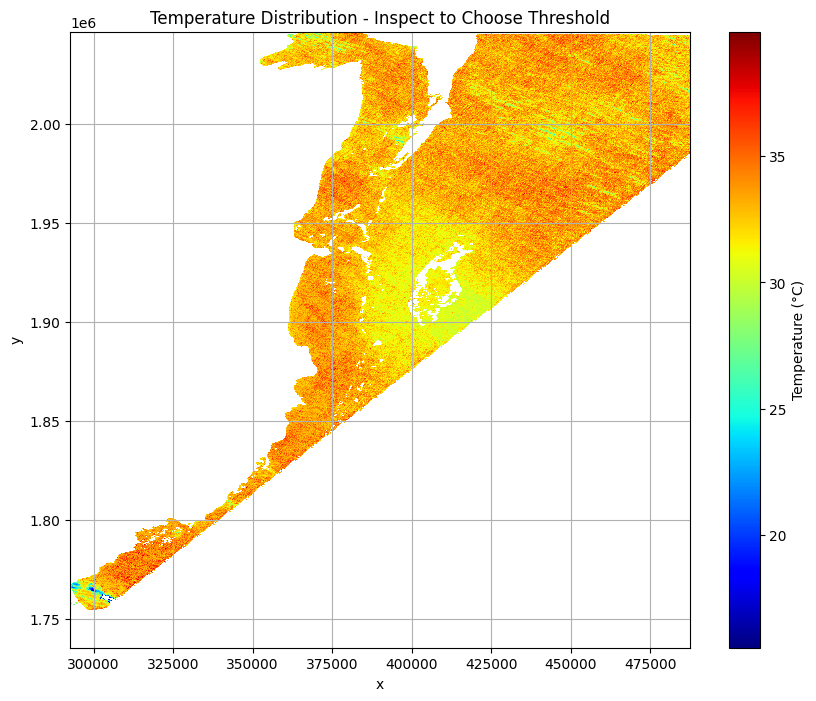

In [ ]:
# ============================================================
# Step 1a: Static Preview — Inspect Temperature Distribution
# ============================================================
# Load the land-masked LST GeoTIFF and display a static map.
# Use the color bar to identify the temperature below which
# cloud-contaminated pixels appear as anomalously cold regions.
# Record this value — you will enter it as TEMP_THRESHOLD_C in Step 2.
# ============================================================

import rioxarray as rxr
import matplotlib.pyplot as plt

# --- User configuration ---
# Set this to the land-masked LST GeoTIFF you want to inspect and clean.
lst_celsius_file = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/Geolocated LST/<YOUR_MASKED_FILE>.tif"

# --- Load and display ---
lst_data = rxr.open_rasterio(lst_celsius_file, masked=True).squeeze()

plt.figure(figsize=(10, 8))
lst_data.plot(cmap='jet', cbar_kwargs={'label': 'Temperature (°C)'})
plt.title('LST — Inspect to Choose Cloud Threshold')
plt.grid(True)
plt.show()


In [ ]:
# ============================================================
# Step 1b: Interactive Preview — Hover to Inspect Pixel Values
# ============================================================
# Renders an interactive Bokeh map with hover tooltips so you
# can read exact temperature values at cloud-suspect pixels.
# Use this alongside the static map in Step 1a to confirm your
# chosen threshold before applying the filter in Step 2.
#
# Requires lst_data to be loaded in Step 1a first.
# ============================================================

import rioxarray as rxr
import hvplot.xarray
from google.colab import output

# Enable Colab's custom widget manager and set hvplot to use Bokeh
output.enable_custom_widget_manager()
hvplot.extension('bokeh')

# Re-load data in case this cell is run independently
lst_data = rxr.open_rasterio(lst_celsius_file, masked=True).squeeze()

display(lst_data.hvplot.image(
    x='x', y='y', cmap='jet', width=700, height=600,
    clabel='Temperature (°C)', title='Interactive LST Map',
    rasterize=True, grid=True, tools=['hover']
))


Data loaded. Generating interactive plot...


/usr/local/lib/python3.12/dist-packages/cudf/utils/gpu_utils.py:75: UserWarning: Failed to dlopen libcuda.so.1
  warnings.warn(str(e))


BokehModel(combine_events=True, render_bundle={'docs_json': {'673a4478-826e-4c1a-a78c-5db06fc43898': {'version…

Support for third party widgets will remain active for the duration of the session. To disable support:

Applying filter with a 32°C threshold...
Filtering complete. Displaying comparison map...


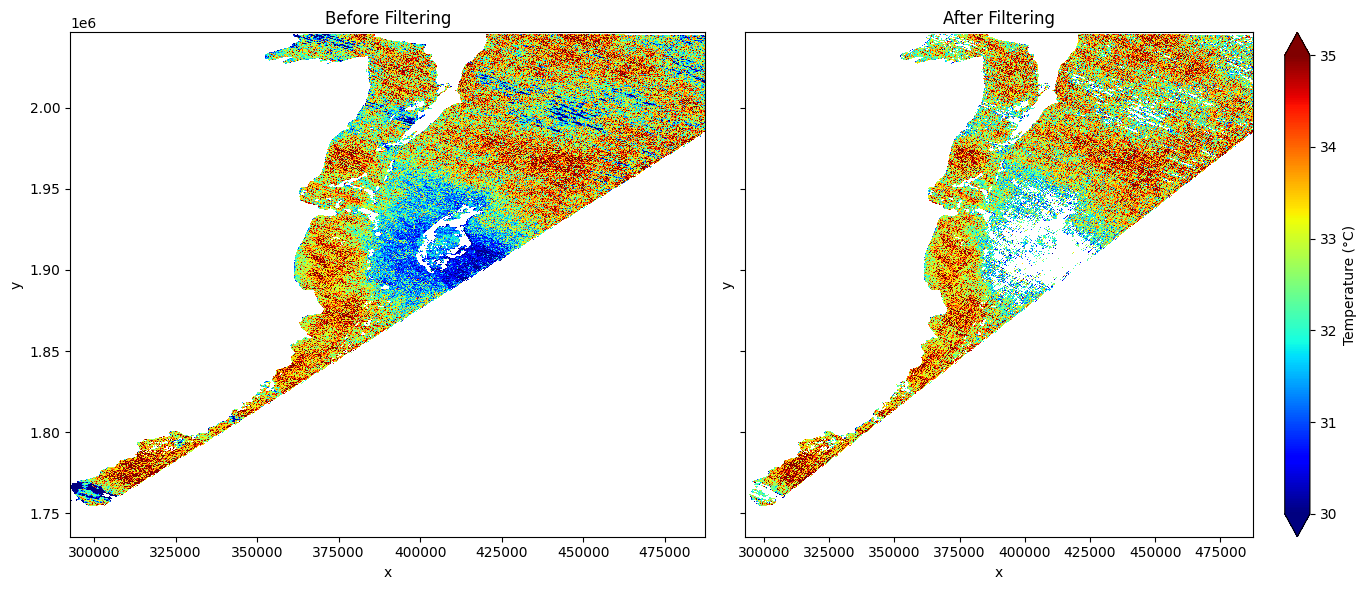

In [ ]:
# ============================================================
# Step 2: Apply Temperature Threshold to Remove Cloud Pixels
# ============================================================
# Cloud-contaminated pixels appear as anomalously cold values in
# the LST image. This step:
#   1. Flags pixels below TEMP_THRESHOLD_C as suspicious.
#   2. Applies morphological opening (binary_opening) to remove
#      small isolated cold pixels that are likely noise rather
#      than true cloud contamination — only contiguous cold
#      regions survive the filter.
#   3. Sets flagged pixels to NaN in the output DataArray.
#   4. Displays a before/after comparison for visual confirmation.
#
# Tune TEMP_THRESHOLD_C based on your Step 1 inspection.
# FILTER_STRUCTURE controls the morphological kernel size;
# the default 3×3 ones kernel is appropriate for most scenes.
# ============================================================

import numpy as np
from scipy.ndimage import binary_opening
import matplotlib.pyplot as plt

# --- User configuration ---
# Temperature (°C) below which pixels are flagged as cloud-contaminated.
# Set this based on your inspection of the map in Step 1.
TEMP_THRESHOLD_C = 32

# Morphological structuring element for opening.
# A 3×3 block of True values retains only connected cold regions
# and discards isolated single-pixel artifacts.
FILTER_STRUCTURE = np.ones((3, 3), dtype=bool)

# --- Apply threshold filter ---
# Flag pixels below the threshold
suspicious_mask = lst_data < TEMP_THRESHOLD_C

# Remove small isolated cold pixels via morphological opening
cleaned_mask_np = binary_opening(suspicious_mask.values, structure=FILTER_STRUCTURE)

# Wrap the cleaned numpy mask back into an xarray DataArray (preserves spatial metadata)
cleaned_mask_da = lst_data.copy(data=cleaned_mask_np)

# Apply mask: set flagged pixels to NaN
final_data = lst_data.where(~cleaned_mask_da)

# --- Before/after comparison ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
lst_data.plot(ax=axes[0], cmap='jet', vmin=TEMP_THRESHOLD_C - 2, vmax=35, add_colorbar=False)
axes[0].set_title('Before Filtering')
final_data.plot(ax=axes[1], cmap='jet', vmin=TEMP_THRESHOLD_C - 2, vmax=35, cbar_kwargs={'label': 'Temperature (°C)'})
axes[1].set_title('After Filtering')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Step 3: Save the Cloud-Filtered Raster
# ============================================================
# Writes final_data to a GeoTIFF in the specified output directory.
# CRS and spatial metadata are carried over automatically by rioxarray.
# The output directory is created if it does not already exist.
# ============================================================

import os

# --- User configuration ---
# Folder where the cloud-filtered GeoTIFF will be saved.
output_directory = "/content/drive/MyDrive/<YOUR_PROJECT_FOLDER>/ECOSTRESS Tifs/Geolocated LST/cloudmasked_output"

# Output filename — typically the same as the input with a 'cloudmasked_' prefix.
output_filename = "cloudmasked_<YOUR_MASKED_FILE>.tif"
output_file = os.path.join(output_directory, output_filename)

# --- Save ---
os.makedirs(output_directory, exist_ok=True)
final_data.rio.to_raster(output_file)


Ensuring output directory exists: /content/drive/MyDrive/Coral PDRDF/ECOSTRESS Tifs/Geolocated LST/cloudmasked_output
Saving final cleaned raster to: /content/drive/MyDrive/Coral PDRDF/ECOSTRESS Tifs/Geolocated LST/cloudmasked_output/masked_ECO_L2T_LSTE.002_LST_doy2023167112656_aid0001_16N_20230616_0526_watermasked.tif
...Save successful.
